### Duplet / triplet

In [4]:
#DEBAT = "./debates/debat-anti-squat.csv"
#DEBAT = "./debates/questions.csv"
DEBAT = "./debates/debat-sept-dec-2025.csv"


In [2]:
colors = {
    "RE": "#ffd60a",
    "GOUV": "#ffd60a",
    "LFI-NUPES": "#dc2f02",
    "ECOLO": "#2b9348",
    "GDR-NUPES": "#dc2f02",
    "LIOT": "#ffd60a",
    "RN": "#003459",
    "LR": "#0466c8",
    "DEM": "#ffd60a",
    "SOC": "#ff758f",
    "HOR": "#ffd60a",
    "NI": "#8a817c",
    "DR": "#0466c8",
    "ECOS": "#2b9348",
    "EPR": "#ffd60a",
    "GDR": "#dc2f02",
    "LFI-NFP": "#dc2f02",
    "UDDPLR": "#003459",
    "UDR": "#003459",
}

In [5]:
import pandas as pd

interventions = pd.read_csv(DEBAT)
interventions = interventions[interventions["speaker_group"].apply(lambda a: "GOUV" not in a)]
interventions = interventions[interventions["speech"].apply(lambda a: len(a) > 30)]

texts = interventions["speech"].tolist()
groups = interventions["speaker_group"].tolist()

In [6]:
experiences = (
    ("baseline", "Lajavaness/sentence-camembert-base"),
    ("tuplet", "./model-triplet"),
    ("tuplet+duplet", "./model-duplet"),
)

/Users/cesarpichon/Documents/bert-mlp/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 314/314 [01:09<00:00,  4.53it/s]
/Users/cesarpichon/Documents/bert-mlp/.venv/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


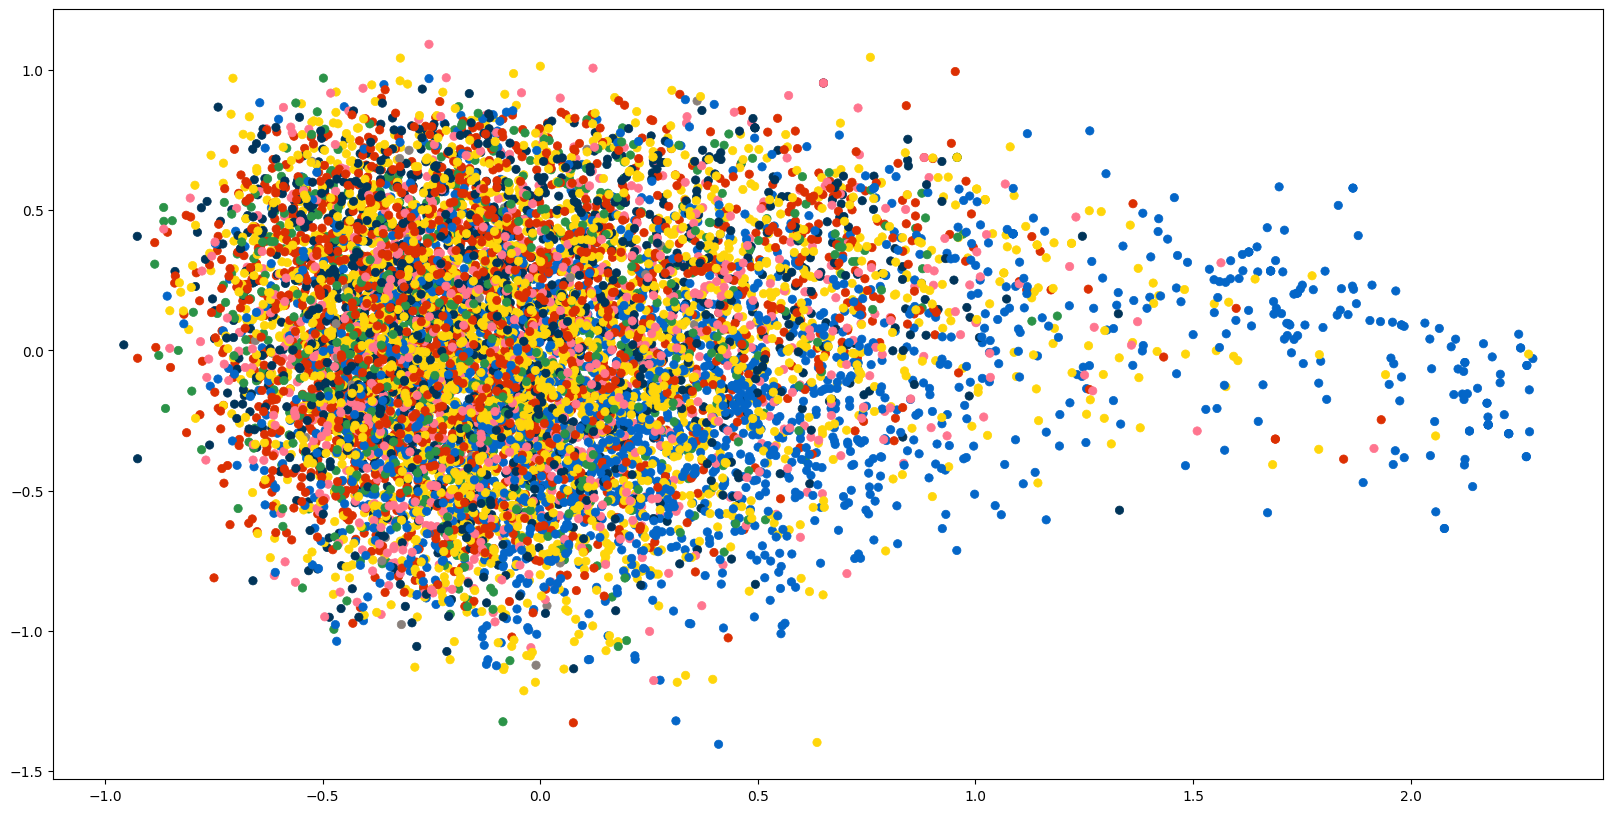

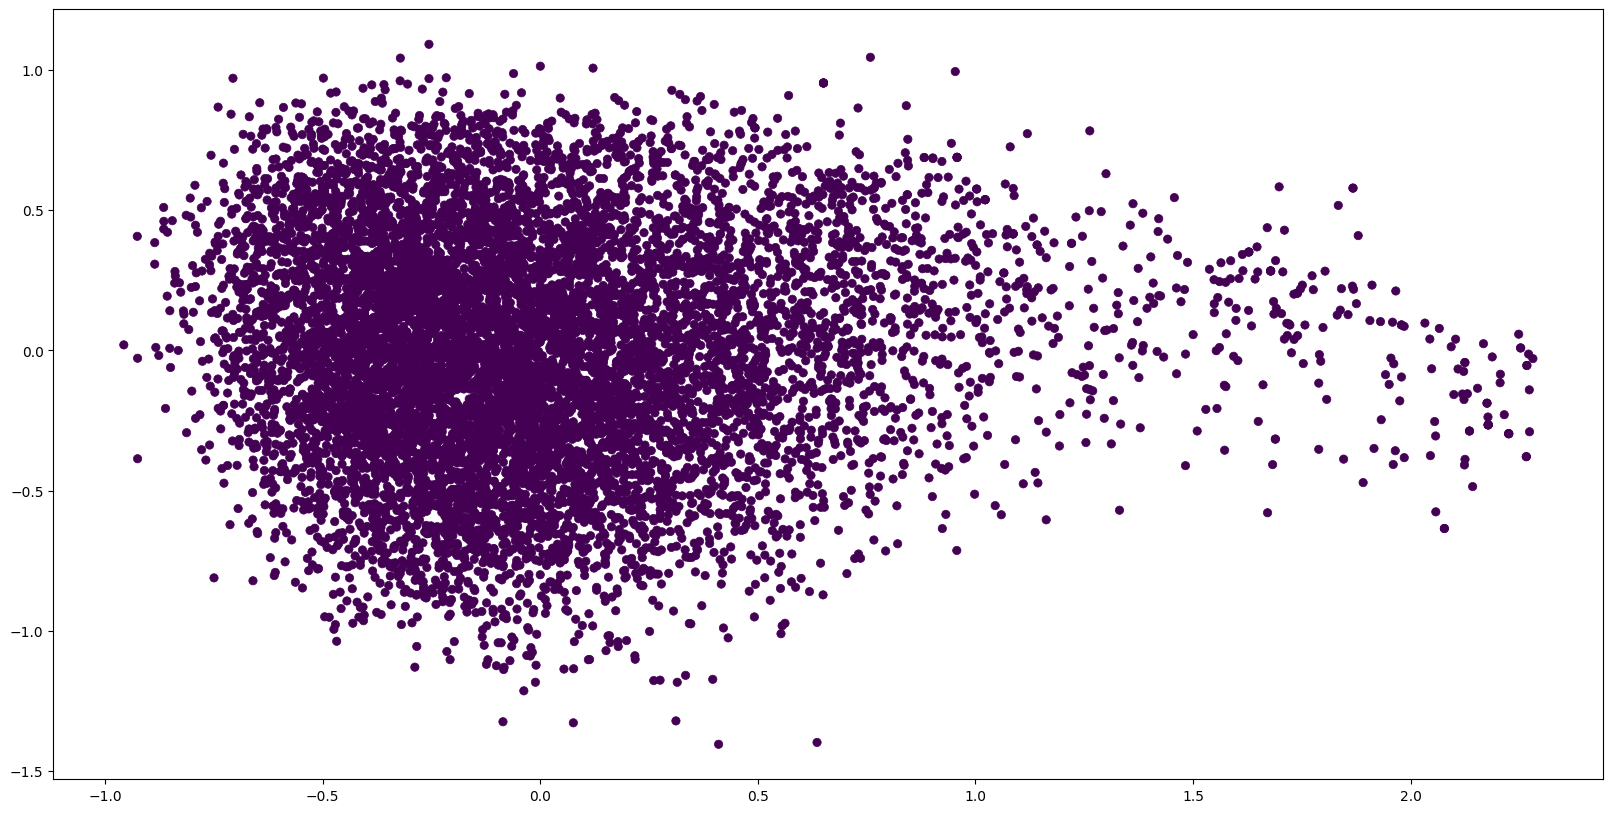

Batches: 100%|██████████| 314/314 [01:08<00:00,  4.58it/s]
/Users/cesarpichon/Documents/bert-mlp/.venv/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


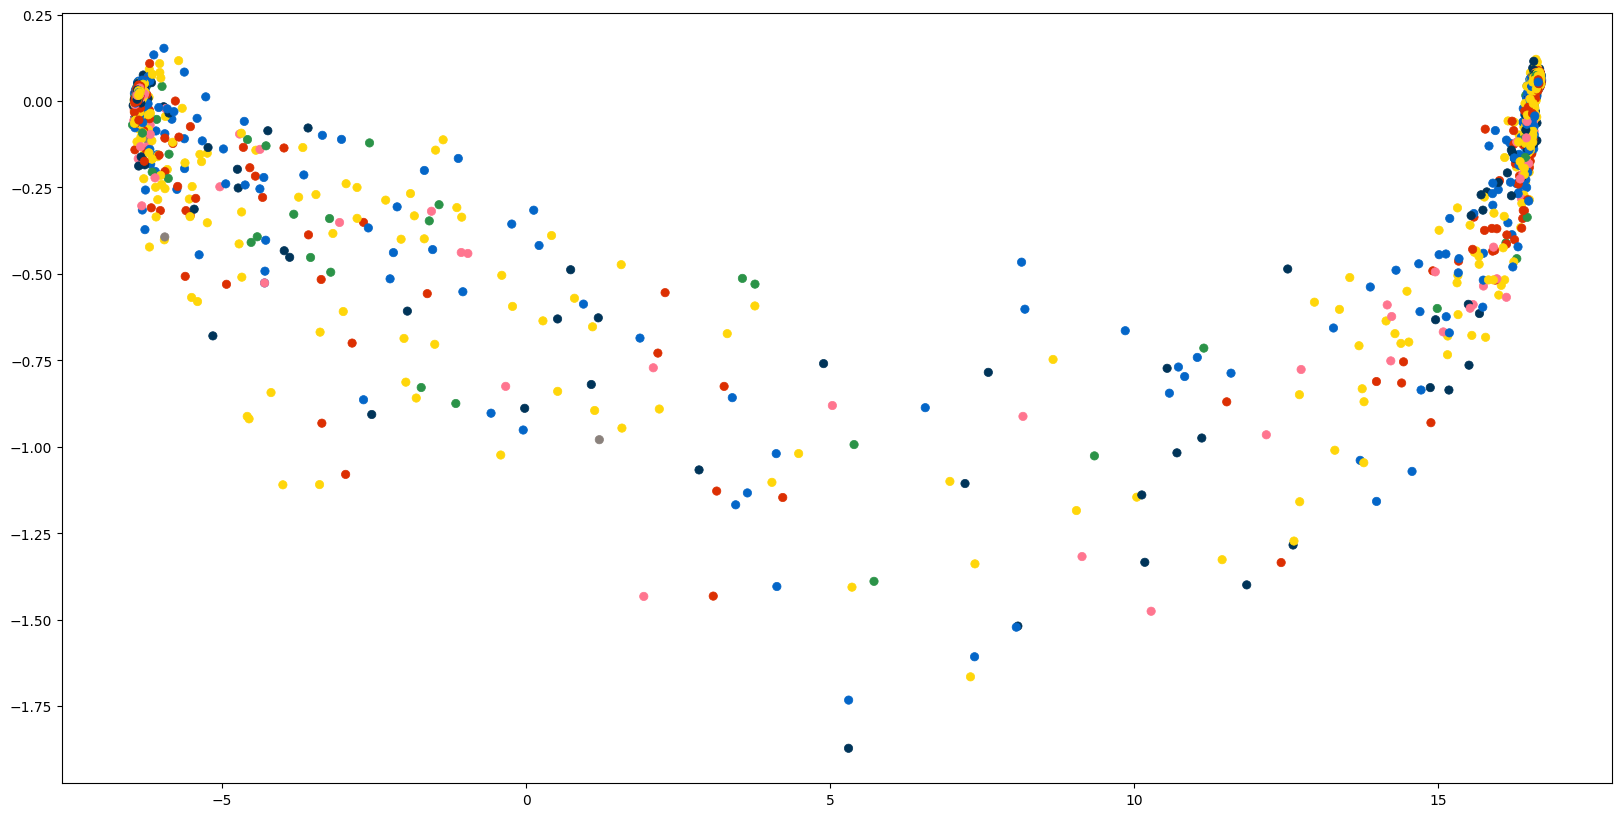

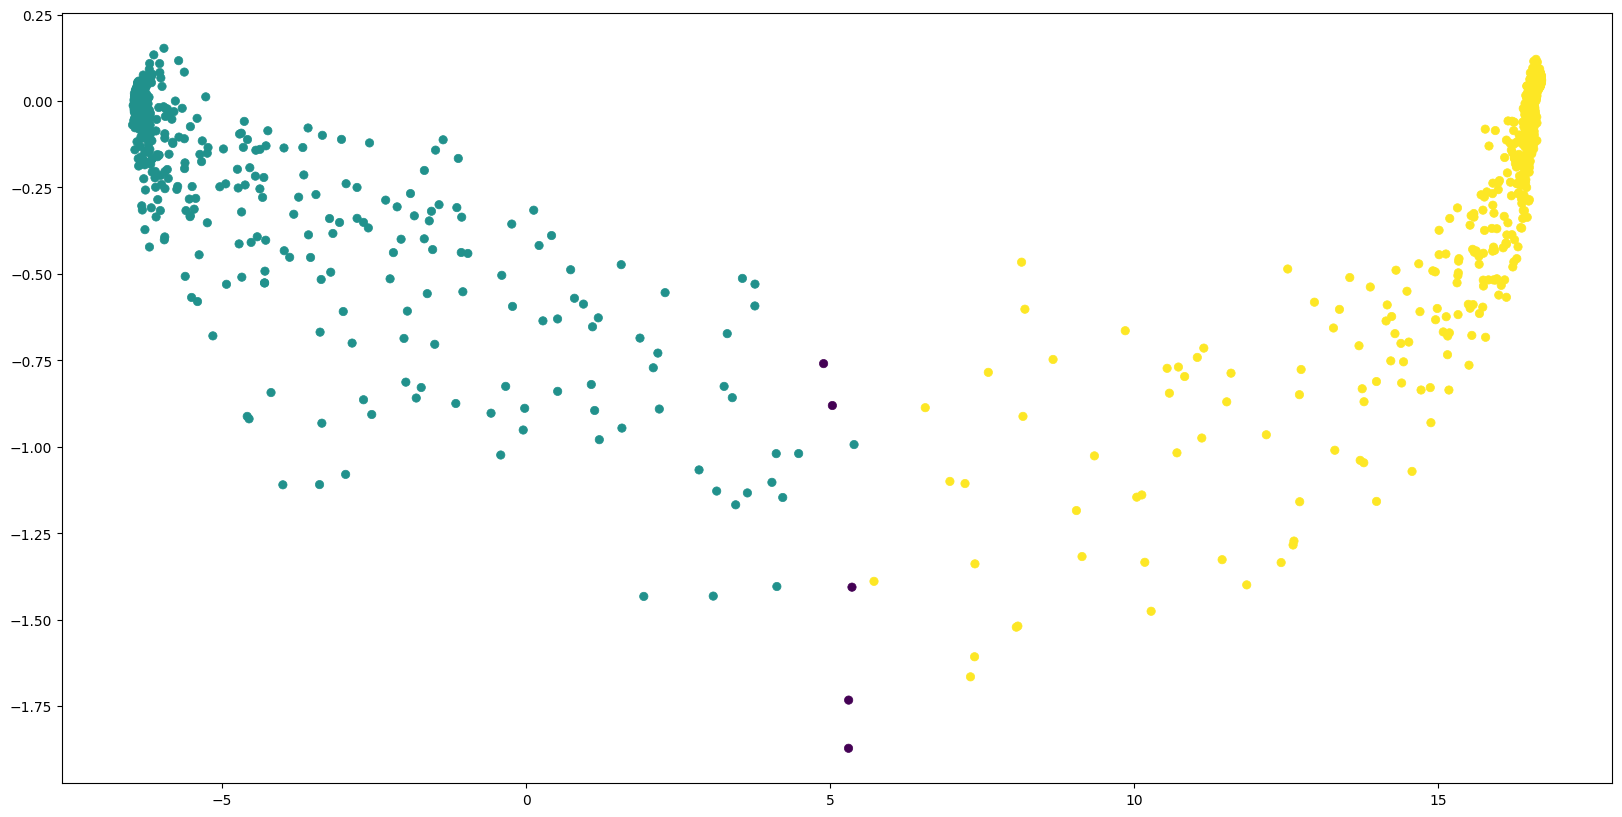

Batches: 100%|██████████| 314/314 [01:06<00:00,  4.72it/s]
/Users/cesarpichon/Documents/bert-mlp/.venv/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


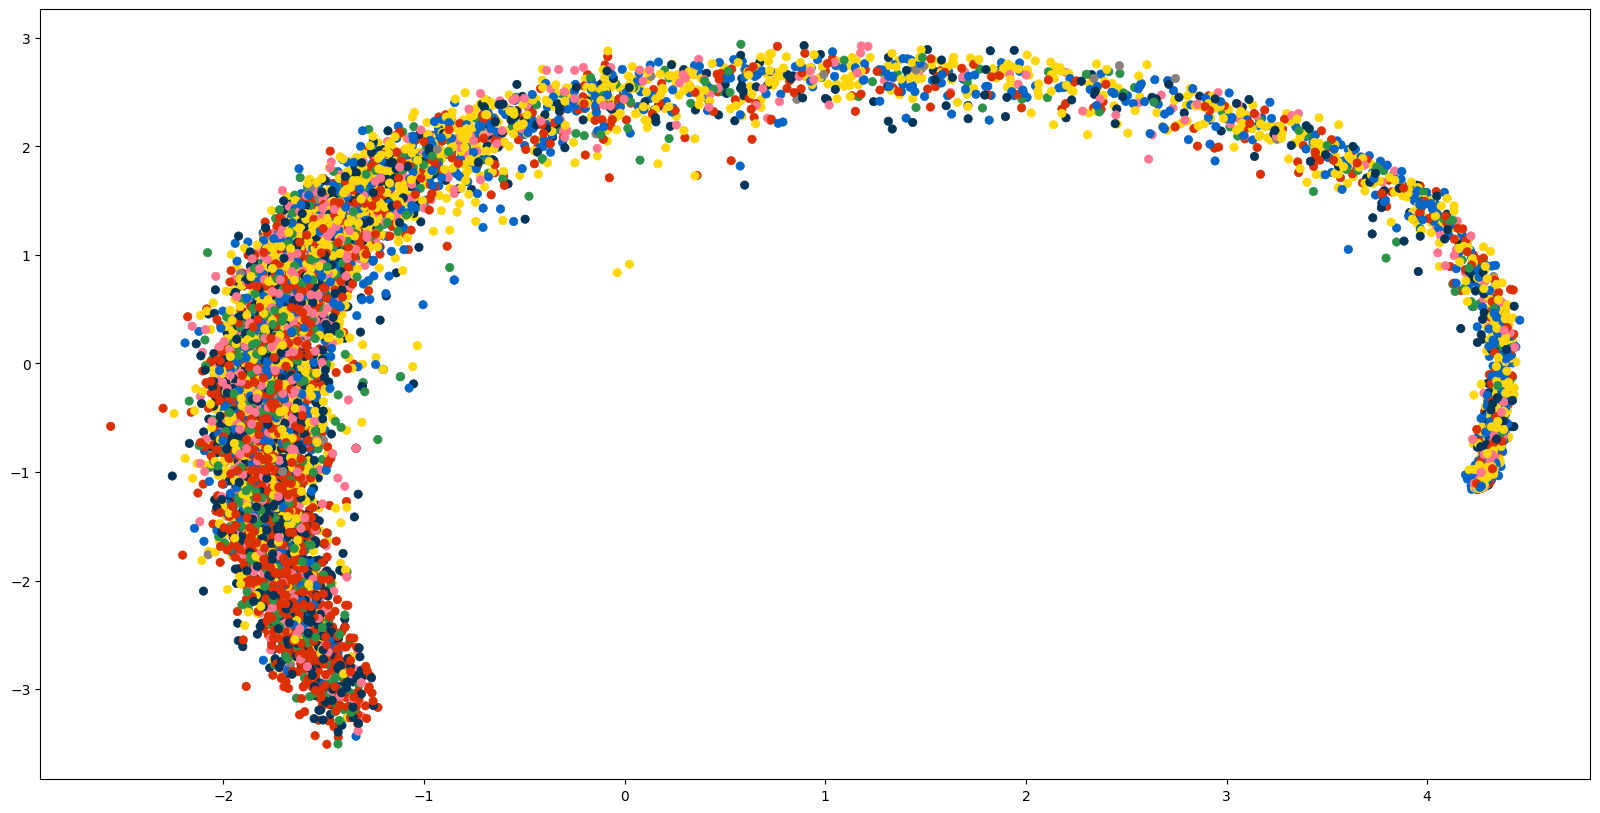

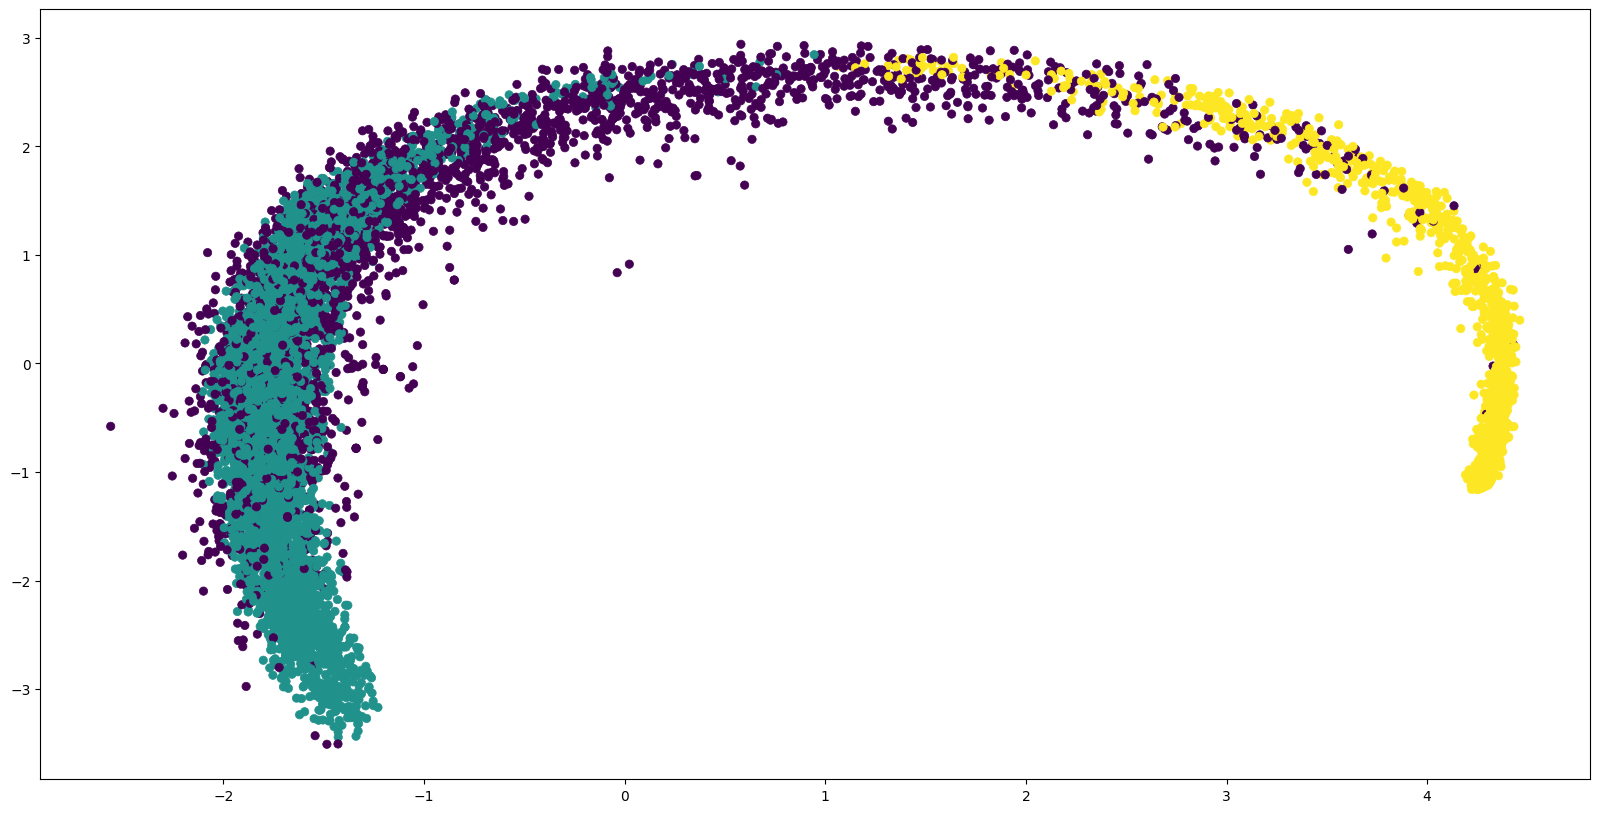

In [7]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN
import matplotlib.pyplot as plt

for label, model in experiences:
    model = SentenceTransformer(model)
    embeddings = model.encode(texts, show_progress_bar=True)

    # Ensure row alignment
    interventions = interventions.reset_index(drop=True)
    groups = interventions["speaker_group"].tolist()

    clusters = HDBSCAN(metric='cosine', min_cluster_size=20).fit_predict(embeddings)

    # Prefer direct string labels for clarity
    reduced_embeddings = PCA(n_components=2).fit_transform(embeddings)

    plt.subplots(figsize=(20, 10))

    plt.scatter(
        reduced_embeddings[:, 0],
        reduced_embeddings[:, 1],
        color=[colors[k] for k in groups],
        lw=0.5,
    )

    plt.show()

    plt.subplots(figsize=(20, 10))
    
    plt.scatter(
        reduced_embeddings[:, 0],
        reduced_embeddings[:, 1],
        c=clusters,
        lw=0.5,
    )

    
    plt.show()